# Macro Metrics vs Train-Size Ratio

This notebook scans `evaluation_metrics.txt` files from runs like:

- `out/seed*/train_use_*/BySeries_global/evaluation_metrics.txt`
- `out/seed*/train_use_*/BySeries_locals/evaluation_metrics.txt`

It then averages micro and macro metrics over seeds at each train-size ratio and plots separate charts per metric for each average type.

In [260]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Plotting defaults used across experiment scripts
mpl.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": False,
        "pgf.rcfonts": False,
        "pgf.preamble": r"\usepackage{amsfonts}\usepackage{amssymb}\usepackage{amsmath}",
        "lines.linewidth": 1,
    }
)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

In [261]:
def find_out_dir(start: Path | None = None) -> Path:
    """Find the nearest `out/` directory from current working directory upward."""
    start = (start or Path.cwd()).resolve()
    for candidate_root in [start, *start.parents]:
        out_dir = candidate_root / "out"
        if out_dir.exists() and out_dir.is_dir():
            return out_dir
    raise FileNotFoundError("Could not find an `out/` directory from current path upward.")


OUT_DIR = find_out_dir()
METRICS_GLOBS = {
    "Global": "seed*/train_use_*/BySeries_global/evaluation_metrics.txt",
    "Global_window": "seed*/train_use_*/ByWindow_global/evaluation_metrics.txt",
    "Locals": "seed*/train_use_*/BySeries_locals/evaluation_metrics.txt",
}
SHOW_STD_BAND = True  # set False to hide +/- 1 std shading

metric_files = []
for model_scope, pattern in METRICS_GLOBS.items():
    for path in sorted(OUT_DIR.glob(pattern)):
        metric_files.append((model_scope, path))

print(f"Using out dir: {OUT_DIR}")
print(f"Found {len(metric_files)} matching metrics files")
metric_files[:5]

Using out dir: /home/dw/cuTAGI_DW/out
Found 34 matching metrics files


[('Global',
  PosixPath('/home/dw/cuTAGI_DW/out/seed2005/train_use_035/BySeries_global/evaluation_metrics.txt')),
 ('Global',
  PosixPath('/home/dw/cuTAGI_DW/out/seed2005/train_use_050/BySeries_global/evaluation_metrics.txt')),
 ('Global',
  PosixPath('/home/dw/cuTAGI_DW/out/seed2005/train_use_065/BySeries_global/evaluation_metrics.txt')),
 ('Global',
  PosixPath('/home/dw/cuTAGI_DW/out/seed2005/train_use_080/BySeries_global/evaluation_metrics.txt')),
 ('Global',
  PosixPath('/home/dw/cuTAGI_DW/out/seed2005/train_use_100/BySeries_global/evaluation_metrics.txt'))]

In [262]:
SEED_RE = re.compile(r"^seed(\d+)$")
TRAIN_RE = re.compile(r"^train_use_(\d+)$")


def parse_seed_and_ratio(path: Path) -> tuple[int, float, int]:
    seed = None
    ratio_pct = None

    for part in path.parts:
        m_seed = SEED_RE.match(part)
        if m_seed:
            seed = int(m_seed.group(1))

        m_ratio = TRAIN_RE.match(part)
        if m_ratio:
            ratio_pct = int(m_ratio.group(1))

    if seed is None or ratio_pct is None:
        raise ValueError(f"Could not parse seed/ratio from: {path}")

    return seed, ratio_pct / 100.0, ratio_pct


def rows_from_metrics_file(path: Path, model_scope: str) -> list[dict]:
    seed, train_ratio, train_ratio_pct = parse_seed_and_ratio(path)
    df = pd.read_csv(path)

    metric_cols = [c for c in df.columns if c != "Series_ID"]
    macro_row = df.loc[df["Series_ID"] == "Macro_Average"]
    micro_row = df.loc[df["Series_ID"] == "Micro_Average"]

    if macro_row.empty or micro_row.empty:
        raise ValueError(f"Missing Macro_Average/Micro_Average rows in: {path}")

    out_rows = []
    for metric_name in metric_cols:
        out_rows.append(
            {
                "seed": seed,
                "train_ratio": train_ratio,
                "train_ratio_pct": train_ratio_pct,
                "metric": metric_name,
                "average_type": "Macro",
                "model_scope": model_scope,
                "value": float(macro_row.iloc[0][metric_name]),
                "path": str(path),
            }
        )
        out_rows.append(
            {
                "seed": seed,
                "train_ratio": train_ratio,
                "train_ratio_pct": train_ratio_pct,
                "metric": metric_name,
                "average_type": "Micro",
                "model_scope": model_scope,
                "value": float(micro_row.iloc[0][metric_name]),
                "path": str(path),
            }
        )

    return out_rows


all_rows = []
for model_scope, file_path in metric_files:
    all_rows.extend(rows_from_metrics_file(file_path, model_scope))

metrics_long = pd.DataFrame(all_rows)
metrics_long = metrics_long.sort_values(["metric", "average_type", "model_scope", "train_ratio", "seed"]).reset_index(drop=True)

print(f"Loaded {len(metrics_long)} rows")
metrics_long.head(12)

Loaded 340 rows


,seed,train_ratio,train_ratio_pct,metric,average_type,model_scope,value,path
0,2005,0.35,35,LogLik,Macro,Global,-657.5997,/home/dw/cuTAGI_DW/out/seed2005/train_use_035/...
1,2012,0.35,35,LogLik,Macro,Global,-1151.9799,/home/dw/cuTAGI_DW/out/seed2012/train_use_035/...
2,2016,0.35,35,LogLik,Macro,Global,-865.6589,/home/dw/cuTAGI_DW/out/seed2016/train_use_035/...
3,2005,0.50,50,LogLik,Macro,Global,-558.6710,/home/dw/cuTAGI_DW/out/seed2005/train_use_050/...
4,2012,0.50,50,LogLik,Macro,Global,-819.1726,/home/dw/cuTAGI_DW/out/seed2012/train_use_050/...
5,2016,0.50,50,LogLik,Macro,Global,-803.4250,/home/dw/cuTAGI_DW/out/seed2016/train_use_050/...
6,2005,0.65,65,LogLik,Macro,Global,-499.3341,/home/dw/cuTAGI_DW/out/seed2005/train_use_065/...
7,2012,0.65,65,LogLik,Macro,Global,-905.2283,/home/dw/cuTAGI_DW/out/seed2012/train_use_065/...
8,2016,0.65,65,LogLik,Macro,Global,-679.2306,/home/dw/cuTAGI_DW/out/seed2016/train_use_065/...
9,2005,0.80,80,LogLik,Macro,Global,-466.2733,/home/dw/cuTAGI_DW/out/seed2005/train_use_080/...


In [263]:
seed_coverage = (
    metrics_long.groupby(["train_ratio", "average_type"])["seed"]
    .nunique()
    .rename("n_seeds")
    .reset_index()
    .sort_values(["train_ratio", "average_type"])
)
seed_coverage

,train_ratio,average_type,n_seeds
0,0.35,Macro,3
1,0.35,Micro,3
2,0.50,Macro,3
3,0.50,Micro,3
4,0.65,Macro,3
5,0.65,Micro,3
6,0.80,Macro,3
7,0.80,Micro,3
8,1.00,Macro,3
9,1.00,Micro,3


In [264]:
agg = (
    metrics_long.groupby(["metric", "average_type", "model_scope", "train_ratio", "train_ratio_pct"], as_index=False)
    .agg(
        mean_value=("value", "mean"),
        std_value=("value", "std"),
        n_seeds=("seed", "nunique"),
    )
    .sort_values(["metric", "average_type", "model_scope", "train_ratio"])
)

agg.head(20)

,metric,average_type,model_scope,train_ratio,train_ratio_pct,mean_value,std_value,n_seeds
0,LogLik,Macro,Global,0.35,35,-891.746167,248.220375,3
1,LogLik,Macro,Global,0.50,50,-727.089533,146.067103,3
2,LogLik,Macro,Global,0.65,65,-694.597667,203.382977,3
3,LogLik,Macro,Global,0.80,80,-670.637267,183.506887,3
4,LogLik,Macro,Global,1.00,100,-787.534467,255.905466,3
5,LogLik,Macro,Global_window,0.35,35,-946.564400,NaN,1
6,LogLik,Macro,Global_window,0.50,50,-1013.336200,NaN,1
7,LogLik,Macro,Global_window,0.65,65,-1503.505900,NaN,1
8,LogLik,Macro,Global_window,0.80,80,-672.572900,NaN,1
9,LogLik,Macro,Locals,0.35,35,-144.331500,5.197406,3


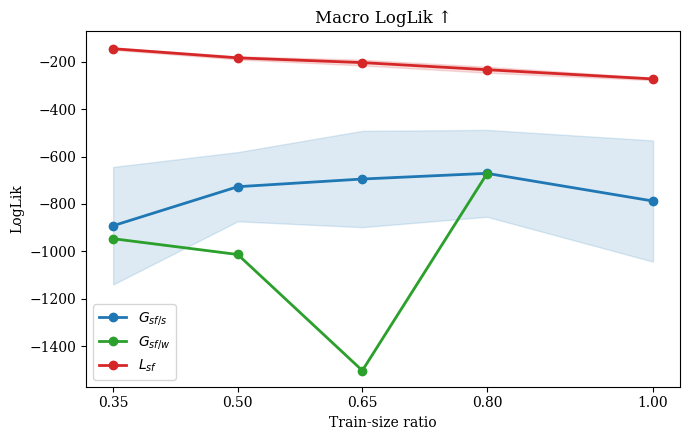

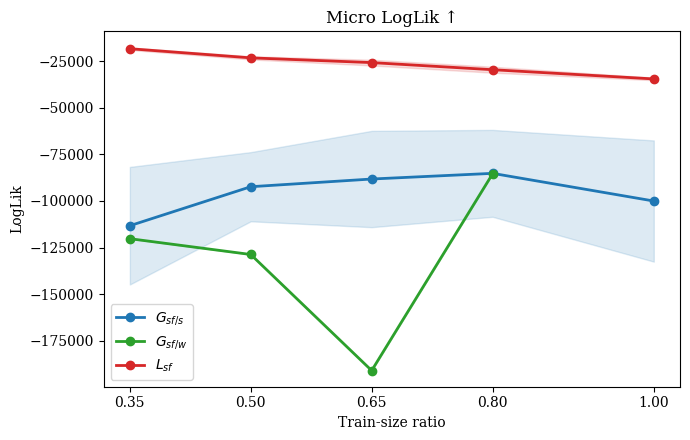

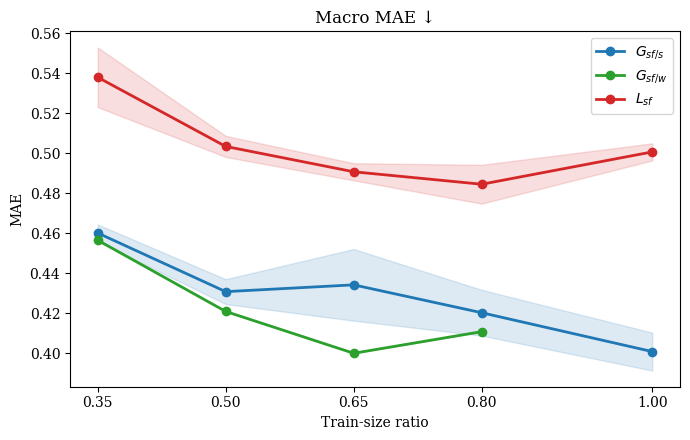

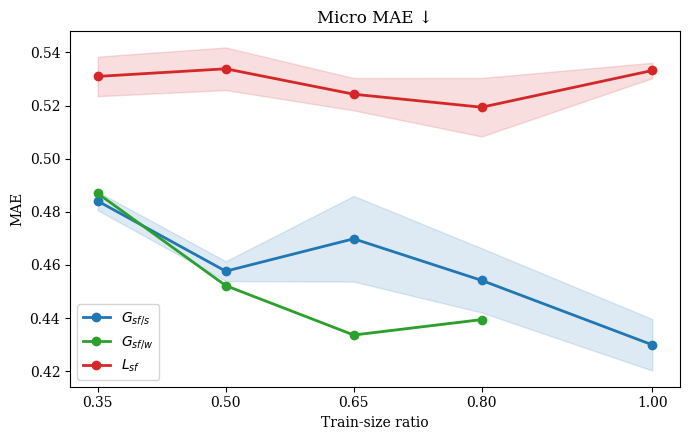

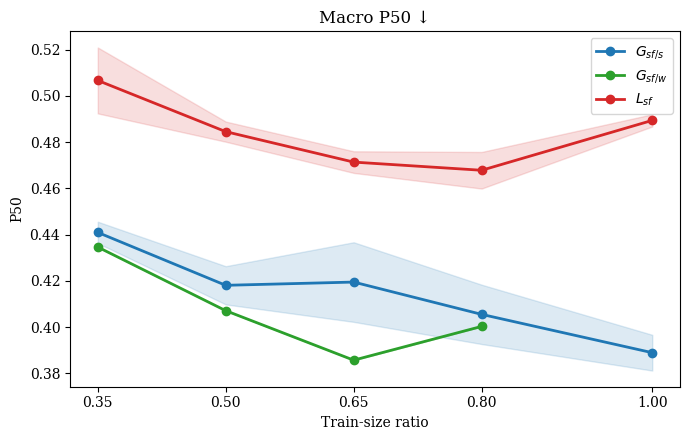

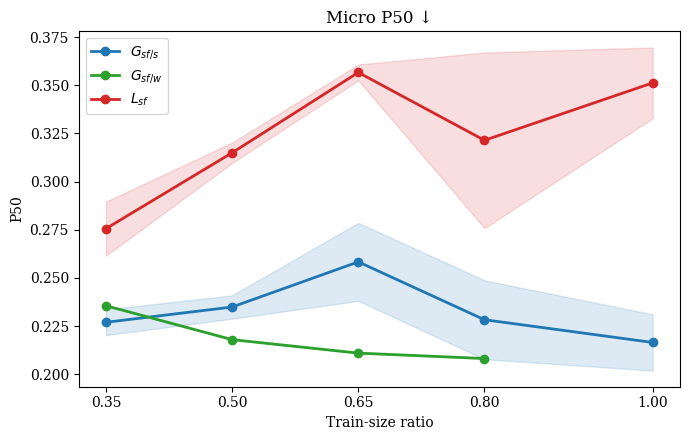

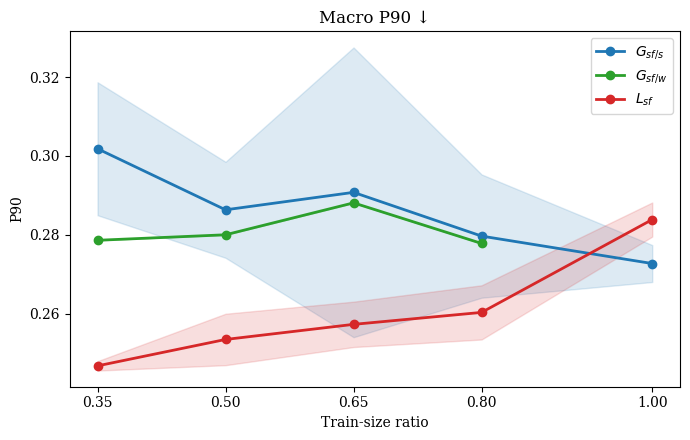

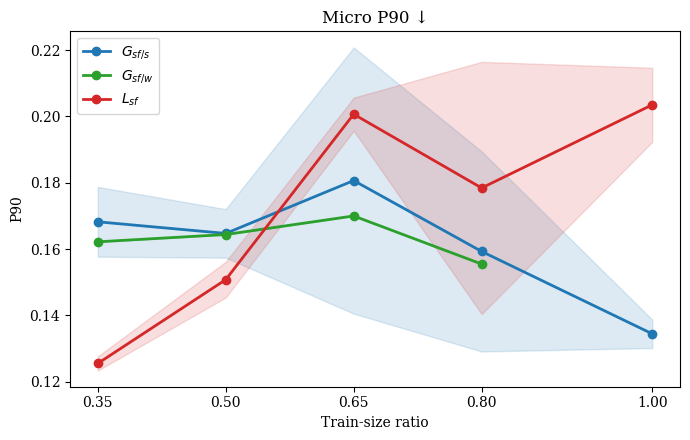

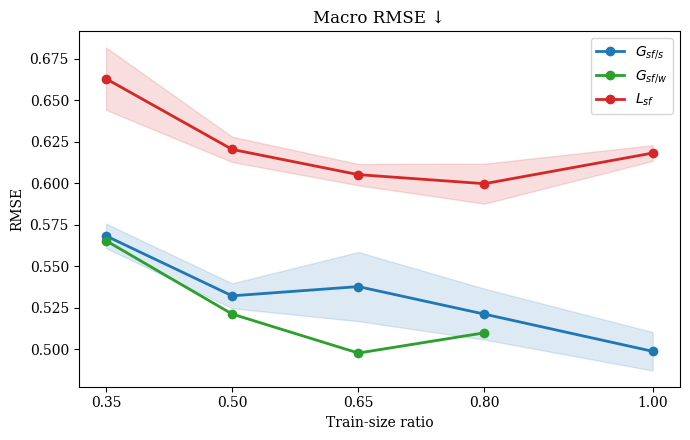

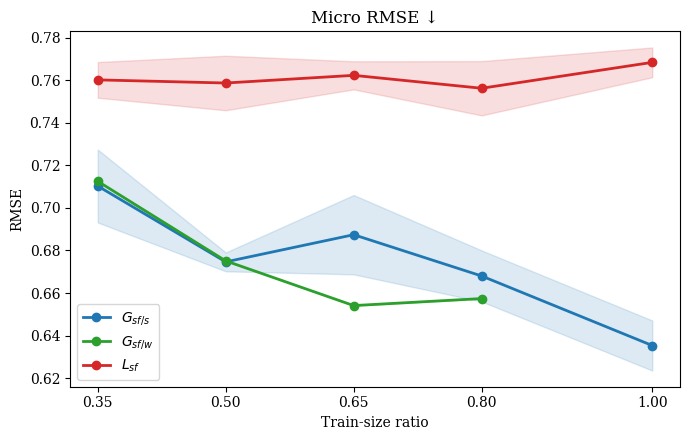

In [265]:
metrics = sorted(agg["metric"].unique())
better_direction = {
    "LogLik": "up",
    "RMSE": "down",
    "MAE": "down",
    "P50": "down",
    "P90": "down",
}
line_styles = {
    "Global": {"color": "tab:blue", "label": r"$G_{sf/s}$"},
    "Global_window": {"color": "tab:green", "label": r"$G_{sf/w}$"},
    "Locals": {"color": "tab:red", "label": r"$L_{sf}$"},
}
average_types = ["Macro", "Micro"]
x_ticks = sorted(agg["train_ratio"].unique())

for metric in metrics:
    for average_type in average_types:
        fig, ax = plt.subplots(figsize=(7, 4.5))

        for model_scope, style in line_styles.items():
            sub = (
                agg[
                    (agg["metric"] == metric)
                    & (agg["average_type"] == average_type)
                    & (agg["model_scope"] == model_scope)
                ]
                .sort_values("train_ratio")
                .reset_index(drop=True)
            )
            if sub.empty:
                continue

            x = sub["train_ratio"].to_numpy()
            y = sub["mean_value"].to_numpy()
            y_std = sub["std_value"].fillna(0.0).to_numpy()

            ax.plot(x, y, marker="o", linewidth=2.0, color=style["color"], label=style["label"])
            if SHOW_STD_BAND:
                ax.fill_between(x, y - y_std, y + y_std, color=style["color"], alpha=0.15)

        arrow = "↑" if better_direction.get(metric, "down") == "up" else "↓"
        ax.set_title(f"{average_type} {metric} {arrow}")
        ax.set_xlabel("Train-size ratio")
        ax.set_ylabel(metric)
        ax.set_xticks(x_ticks)
        ax.legend()
        fig.tight_layout()
        plt.show()


In [266]:
# Optional: save aggregated table for later use
save_path = OUT_DIR / "macro_micro_metrics_avg_over_seeds.csv"
agg.to_csv(save_path, index=False)
print(f"Saved: {save_path}")

Saved: /home/dw/cuTAGI_DW/out/macro_micro_metrics_avg_over_seeds.csv
